In [ ]:

# INTENTIONALLY MISSING: 
# torch.manual_seed(42)
# np.random.seed(42)
# No requirements.txt 

Fetching the 8x8 digits dataset...
Success! simple_digits.csv saved.
Loading data into the GAN...
Starting training...
Epoch 0 | D Loss: 1.3733 | G Loss: 0.7889
Epoch 200 | D Loss: 0.2391 | G Loss: 5.3823
Epoch 400 | D Loss: 0.1269 | G Loss: 4.7636
Epoch 600 | D Loss: 0.2438 | G Loss: 3.3657
Epoch 800 | D Loss: 0.7269 | G Loss: 1.9382
Training complete. Generating sample...


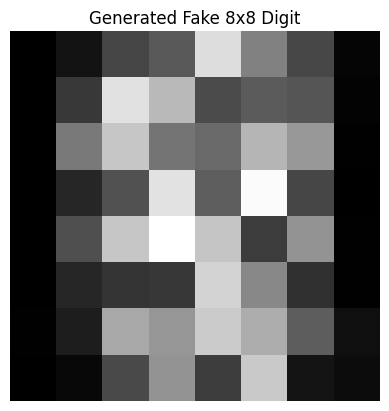

In [ ]:
import os
# Fix for the Windows/Anaconda DLL kernel crash
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import pandas as  pd
import numpy as np
from sklearn.datasets import load_digits
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ==========================================
# 1. GENERATE THE DATASET
# ==========================================
print("Fetching the 8x8 digits dataset...")
digits = load_digits()
df_initial = pd.DataFrame(digits.data)
df_initial.to_csv("simple_digits.csv", index=False)
print("Success! simple_digits.csv saved.")

# ==========================================
# 2. LOAD AND PREPARE DATA FOR GAN
# ==========================================
print("Loading data into the GAN...")
df = pd.read_csv("simple_digits.csv")
real_data = torch.tensor(df.values, dtype=torch.float32) / 16.0

# ==========================================
# 3. DEFINE THE GAN ARCHITECTURE
# ==========================================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.Sigmoid() 
        )
    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

# ==========================================
# 4. INITIALIZE MODELS & OPTIMIZERS
# ==========================================
G = Generator()
D = Discriminator()
criterion = nn.BCELoss()
d_optimizer = optim.Adam(D.parameters(), lr=0.001)
g_optimizer = optim.Adam(G.parameters(), lr=0.001)

# ==========================================
# 5. TRAINING LOOP
# ==========================================
epochs = 1000 
batch_size = 32
latent_dim = 32

print("Starting training...")
for epoch in range(epochs):
    # Train Discriminator
    indices = torch.randint(0, len(real_data), (batch_size,))
    real_batch = real_data[indices]
    
    noise = torch.randn(batch_size, latent_dim)
    fake_batch = G(noise)
    
    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)
    
    d_loss_real = criterion(D(real_batch), real_labels)
    d_loss_fake = criterion(D(fake_batch.detach()), fake_labels)
    d_loss = d_loss_real + d_loss_fake
    
    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()
    
    # Train Generator
    noise = torch.randn(batch_size, latent_dim)
    fake_batch = G(noise)
    g_loss = criterion(D(fake_batch), real_labels)
    
    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

# ==========================================
# 6. GENERATE FAKE DIGIT
# ==========================================
print("Training complete. Generating sample...")
test_noise = torch.randn(1, latent_dim)
generated_sample = G(test_noise).detach().numpy().reshape(8, 8)

plt.imshow(generated_sample, cmap='gray')
plt.title("Generated Fake 8x8 Digit")
plt.axis('off')
plt.show()